In [4]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import time
from datetime import datetime
import os

# ─── Configuration ─────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
RECORD_SECONDS = 5        # duration per session
NUM_WALKING = 20           # number of walking sessions
NUM_FALLING = 20           # number of falling sessions
BASE_OUTPUT_DIR = "data"  # base folder for all tests
ENABLE_VISUALIZATION = False  # optional visualization (set True to show plots)

os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

# ─── Function to Record One Session ───────────────────────────
def record_session(label, session_number, test_id, test_folder):
    data_points = []
    collecting = True

    def on_connect(client, userdata, flags, rc):
        if rc == 0:
            client.subscribe(MQTT_TOPIC)
        else:
            print("❌ Connection failed:", rc)

    def on_message(client, userdata, msg):
        nonlocal data_points, collecting
        if not collecting:
            return
        payload = msg.payload.decode("utf-8").strip()
        matches = re.findall(r"\[([0-9\.,\- ]+)\]", payload)
        for m in matches:
            vals = [float(x) for x in m.split(",")]
            data_points.append(vals)
        print(f"📡 {label} {session_number}: {len(data_points)} samples", end="\r")

    client = mqtt.Client()
    client.on_connect = on_connect
    client.on_message = on_message
    client.connect(BROKER_ADDRESS, 1883, 60)

    print(f"\n▶️ Recording {label.upper()} session {session_number} ({RECORD_SECONDS}s)...")
    client.loop_start()
    start_time = time.time()

    while time.time() - start_time < RECORD_SECONDS:
        time.sleep(0.05)

    collecting = False
    client.loop_stop()
    client.disconnect()

    if len(data_points) == 0:
        print(f"⚠️ No data received for {label} {session_number}")
        return

    df = pd.DataFrame(data_points, columns=["t", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"])
    df["dt"] = df["t"].diff()
    df.loc[df["dt"] < 0, "dt"] += 2**32
    df = df.dropna().reset_index(drop=True)
    df["dt_sec"] = df["dt"] / 1_000_000.0

    avg_freq = 1 / df["dt_sec"].mean()
    jitter_ms = df["dt_sec"].std() * 1000

    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"test_{test_id}_{label}_{session_number}_{len(df)}samples_{RECORD_SECONDS}s.csv"
    filepath = os.path.join(test_folder, filename)
    df.to_csv(filepath, index=False)

    print(f"\n✅ Saved {label} session {session_number} to {filepath}")
    print(f"   Avg freq: {avg_freq:.2f} Hz | Jitter: {jitter_ms:.3f} ms")

# ─── Validate Test ID ──────────────────────────────────────────
def get_valid_test_id():
    while True:
        test_id = input("Enter test number (numbers only, e.g. 01): ").strip()
        if not test_id:
            print("⚠️ Test number cannot be empty. Try again.")
            continue
        if not test_id.isdigit():
            print("⚠️ Invalid test number. Use only digits (no letters or symbols).")
            continue
        return test_id

# ─── Optional Visualization Function ──────────────────────────
def visualize_test_data(test_folder):
    import matplotlib.pyplot as plt
    import numpy as np
    print("\n📊 Visualizing collected CSV data...")
    csv_files = [f for f in os.listdir(test_folder) if f.endswith(".csv")]

    for csv_file in csv_files:
        file_path = os.path.join(test_folder, csv_file)
        df = pd.read_csv(file_path)
        if "acc_x" not in df.columns:
            continue
        df["acc_mag"] = (df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)**0.5
        df["gyro_mag"] = (df["gyro_x"]**2 + df["gyro_y"]**2 + df["gyro_z"]**2)**0.5

        time_axis = range(len(df))

        plt.figure(figsize=(10, 5))
        plt.plot(time_axis, df["acc_x"], label="Acc X")
        plt.plot(time_axis, df["acc_y"], label="Acc Y")
        plt.plot(time_axis, df["acc_z"], label="Acc Z")
        plt.plot(time_axis, df["acc_mag"], label="Acc Magnitude", color="black", linestyle="--")
        plt.title(f"Accelerometer — {csv_file}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(time_axis, df["gyro_x"], label="Gyro X")
        plt.plot(time_axis, df["gyro_y"], label="Gyro Y")
        plt.plot(time_axis, df["gyro_z"], label="Gyro Z")
        plt.plot(time_axis, df["gyro_mag"], label="Gyro Magnitude", color="black", linestyle="--")
        plt.title(f"Gyroscope — {csv_file}")
        plt.legend()
        plt.tight_layout()
        plt.show()

# ─── Main Collection ──────────────────────────────────────────
test_id = get_valid_test_id()
date_str = datetime.now().strftime("%Y%m%d")
test_folder = os.path.join(BASE_OUTPUT_DIR, f"test_{test_id}_{date_str}")
os.makedirs(test_folder, exist_ok=True)

print(f"\n📁 Created folder for this test: {test_folder}")

# Walking sessions (automatic, no Enter required)
print(f"\n🚶 Starting WALKING sessions for Test {test_id}")
for i in range(1, NUM_WALKING + 1):
    print(f"\n▶️ Automatically starting WALKING session {i}/{NUM_WALKING}...")
    record_session("walking", i, test_id, test_folder)
    time.sleep(2)

# Falling sessions (require Enter)
print(f"\n💥 Starting FALLING sessions for Test {test_id}")
for i in range(1, NUM_FALLING + 1):
    input(f"\nPress ENTER when ready for FALLING session {i}/{NUM_FALLING}...")
    record_session("falling", i, test_id, test_folder)
    time.sleep(2)

print(f"\n🎉 All walking and falling sessions completed for Test {test_id}!")
print(f"📦 Results saved in: {test_folder}")

# ─── Optional Visualization ───────────────────────────────────
if ENABLE_VISUALIZATION:
    visualize_test_data(test_folder)
else:
    print("\n📈 Visualization disabled (set ENABLE_VISUALIZATION = True to enable).")



📁 Created folder for this test: data/test_5_20251030

🚶 Starting WALKING sessions for Test 5

▶️ Automatically starting WALKING session 1/20...

▶️ Recording WALKING session 1 (5s)...


/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_77192/2558796633.py:41: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


📡 walking 1: 125 samples
✅ Saved walking session 1 to data/test_5_20251030/test_5_walking_1_124samples_5s.csv
   Avg freq: 24.99 Hz | Jitter: 5.909 ms

▶️ Automatically starting WALKING session 2/20...

▶️ Recording WALKING session 2 (5s)...


/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_77192/2558796633.py:41: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


📡 walking 2: 125 samples
✅ Saved walking session 2 to data/test_5_20251030/test_5_walking_2_124samples_5s.csv
   Avg freq: 25.02 Hz | Jitter: 5.748 ms

▶️ Automatically starting WALKING session 3/20...

▶️ Recording WALKING session 3 (5s)...


...


▶️ Recording FALLING session 18 (5s)...
📡 falling 18: 125 samples
✅ Saved falling session 18 to data/test_5_20251030/test_5_falling_18_124samples_5s.csv
   Avg freq: 25.04 Hz | Jitter: 5.721 ms


/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_77192/2558796633.py:41: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()



▶️ Recording FALLING session 19 (5s)...
📡 falling 19: 110 samples
✅ Saved falling session 19 to data/test_5_20251030/test_5_falling_19_109samples_5s.csv
   Avg freq: 25.05 Hz | Jitter: 5.792 ms


/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_77192/2558796633.py:41: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()



▶️ Recording FALLING session 20 (5s)...
📡 falling 20: 121 samples
✅ Saved falling session 20 to data/test_5_20251030/test_5_falling_20_120samples_5s.csv
   Avg freq: 25.00 Hz | Jitter: 5.842 ms

🎉 All walking and falling sessions completed for Test 5!
📦 Results saved in: data/test_5_20251030

📈 Visualization disabled (set ENABLE_VISUALIZATION = True to enable).


📁 Found 40 CSV files in data/test_1_20251024

📊 Visualizing: test_1_walking_2_134samples_5s.csv


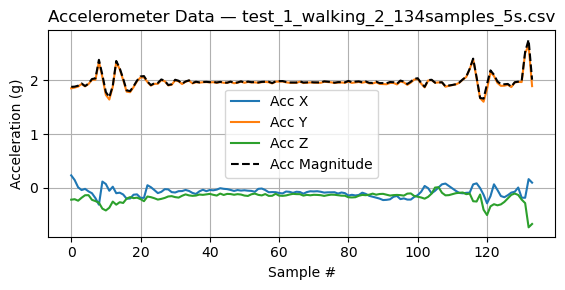

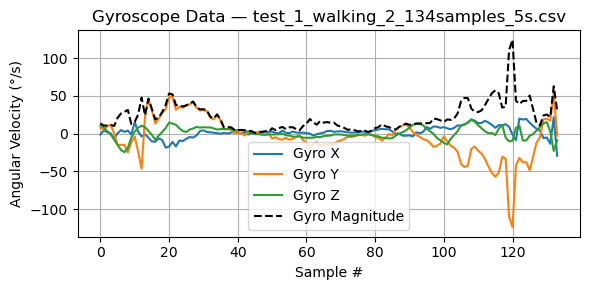

📊 Visualizing: test_1_walking_8_128samples_5s.csv


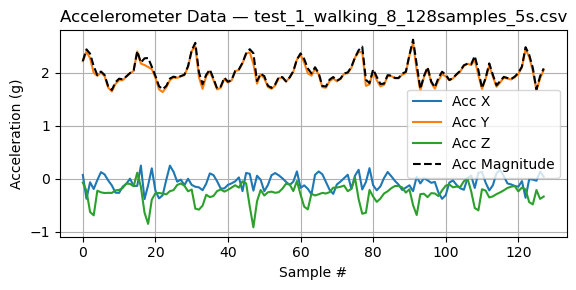

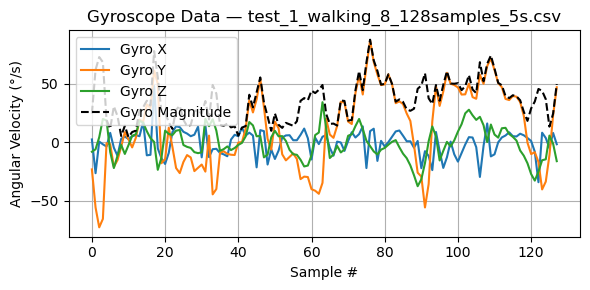

📊 Visualizing: test_1_walking_13_125samples_5s.csv


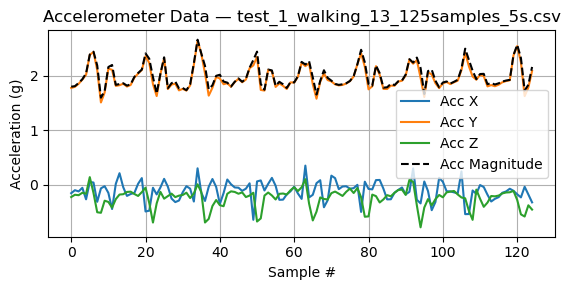

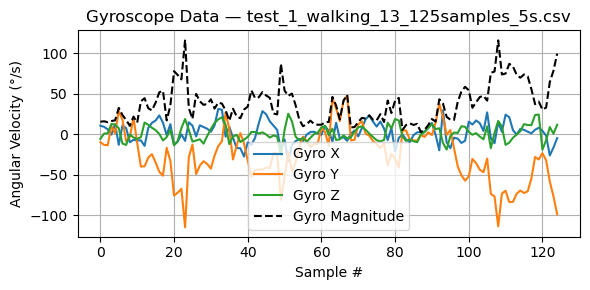

📊 Visualizing: test_1_falling_1_124samples_5s.csv


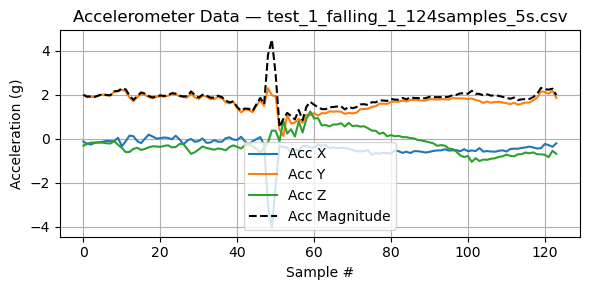

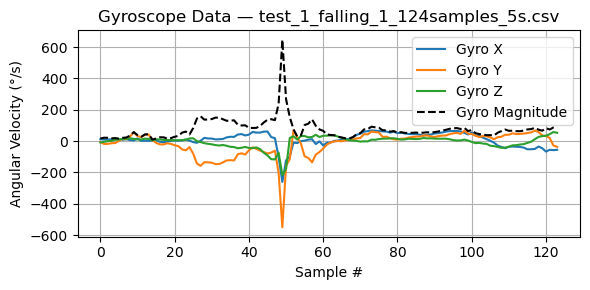

📊 Visualizing: test_1_falling_5_124samples_5s.csv


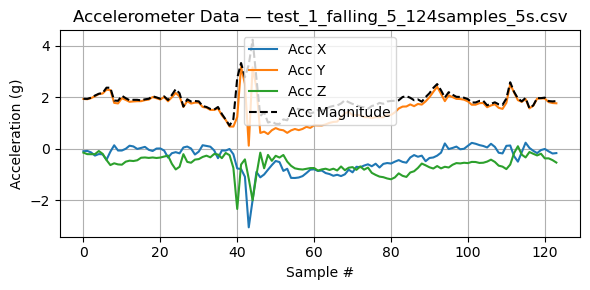

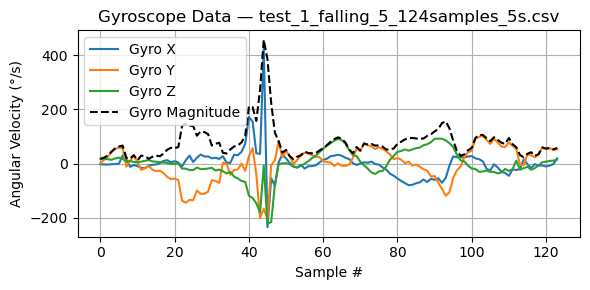

📊 Visualizing: test_1_walking_16_135samples_5s.csv


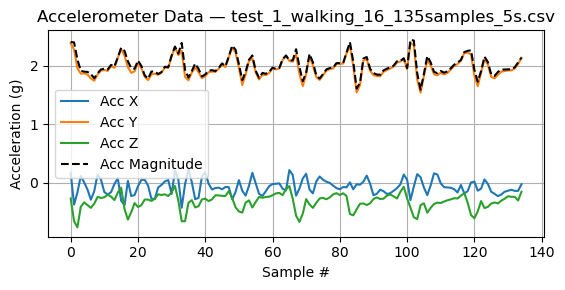

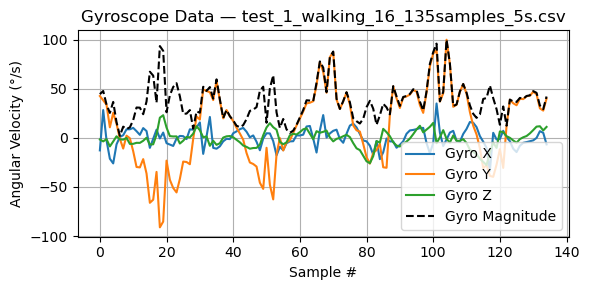

📊 Visualizing: test_1_falling_17_125samples_5s.csv


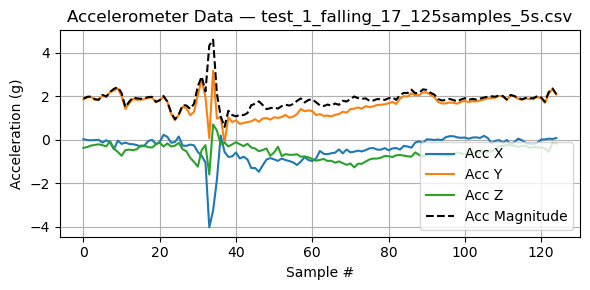

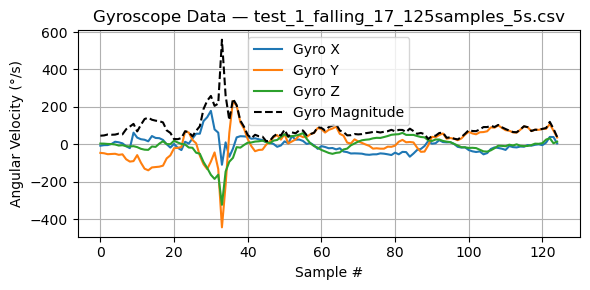

📊 Visualizing: test_1_falling_8_122samples_5s.csv


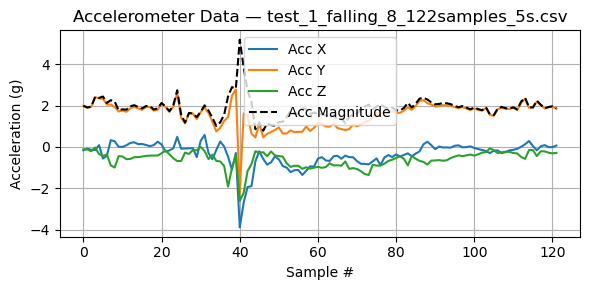

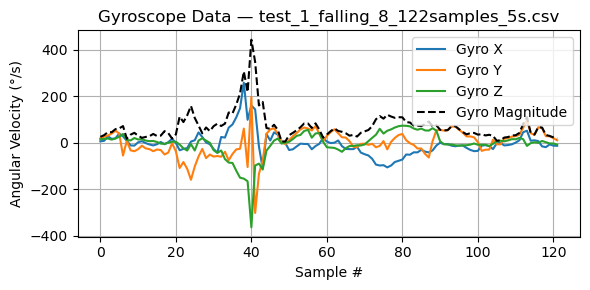

📊 Visualizing: test_1_falling_12_125samples_5s.csv


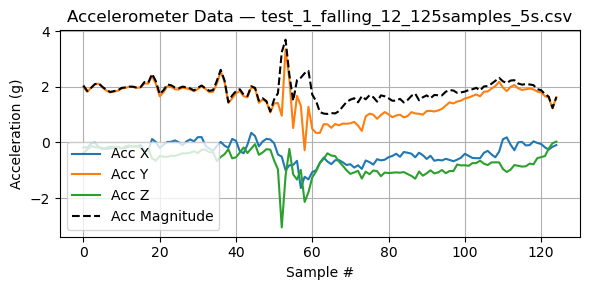

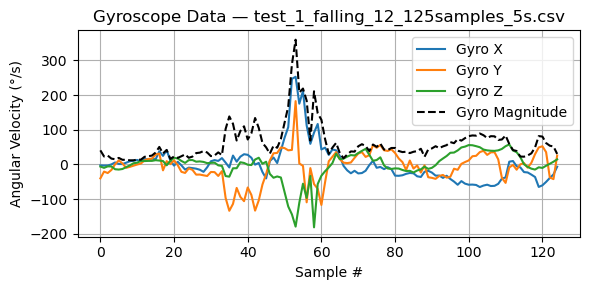

📊 Visualizing: test_1_falling_6_124samples_5s.csv


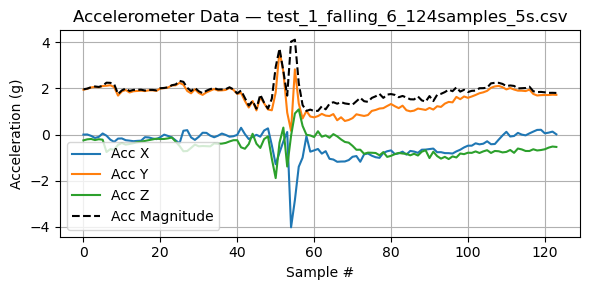

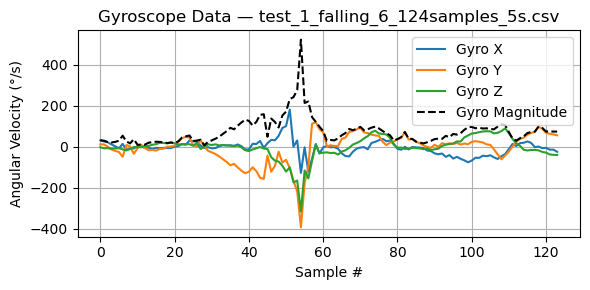

📊 Visualizing: test_1_falling_14_125samples_5s.csv


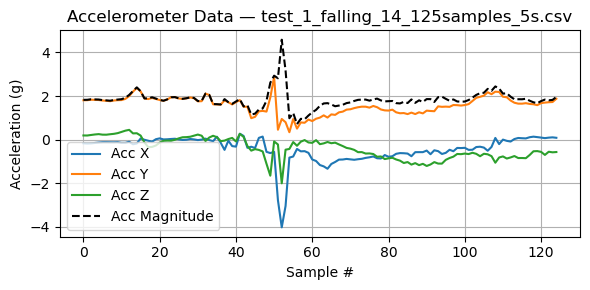

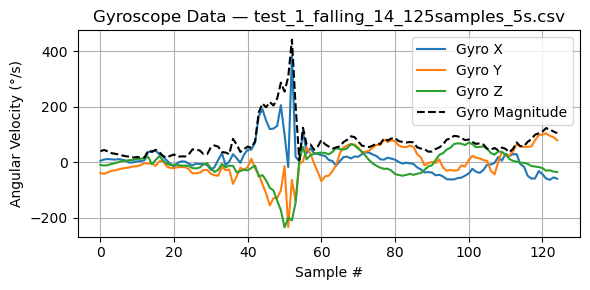

📊 Visualizing: test_1_walking_11_125samples_5s.csv


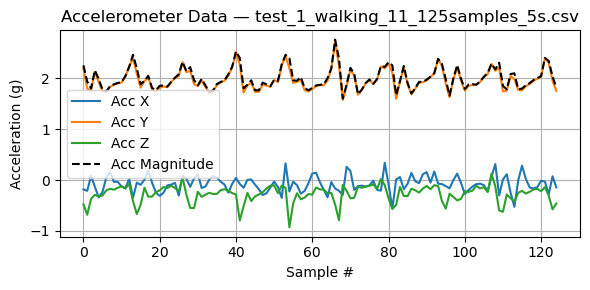

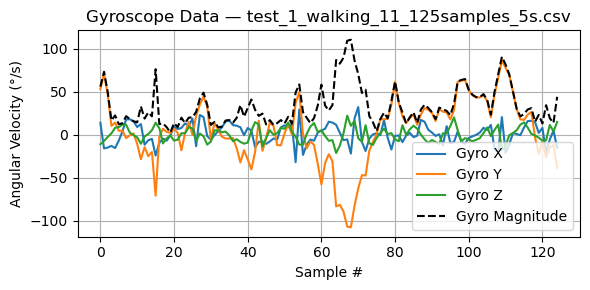

📊 Visualizing: test_1_walking_6_129samples_5s.csv


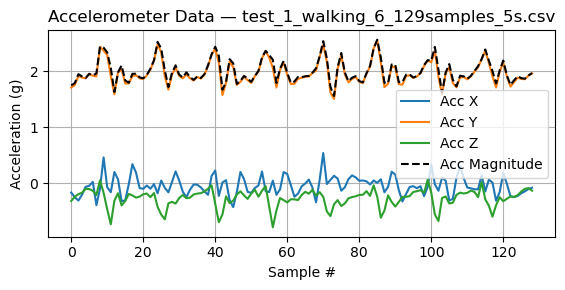

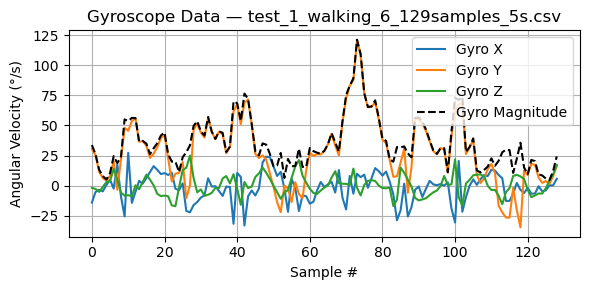

📊 Visualizing: test_1_falling_18_124samples_5s.csv


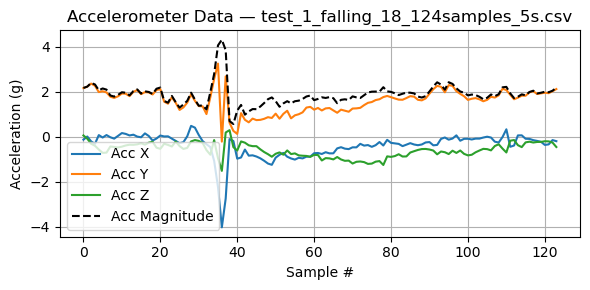

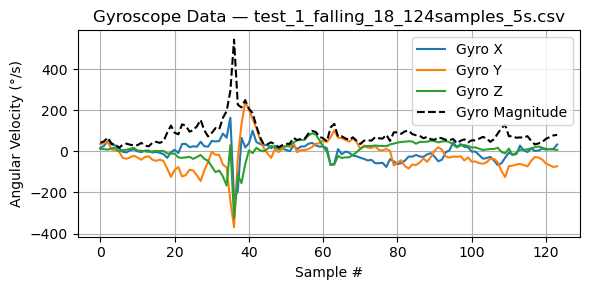

📊 Visualizing: test_1_falling_11_125samples_5s.csv


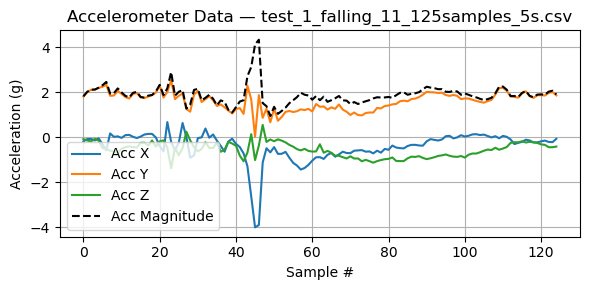

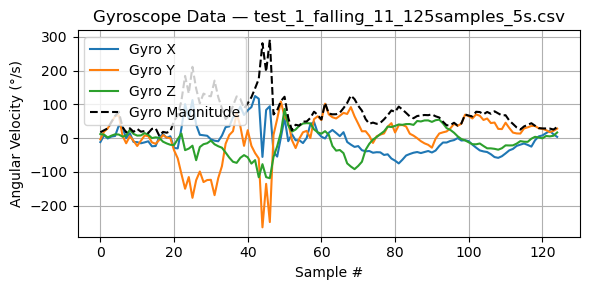

📊 Visualizing: test_1_walking_10_126samples_5s.csv


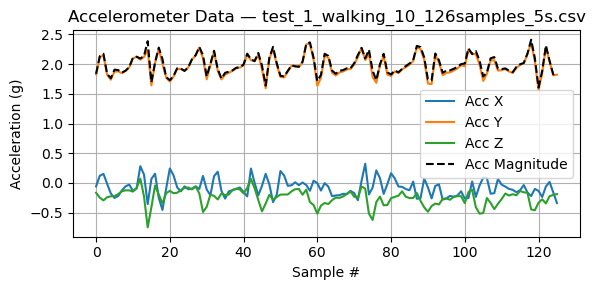

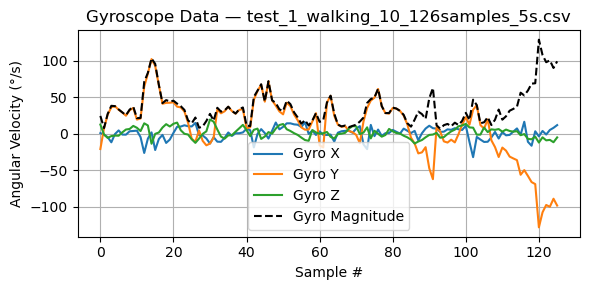

📊 Visualizing: test_1_walking_1_134samples_5s.csv


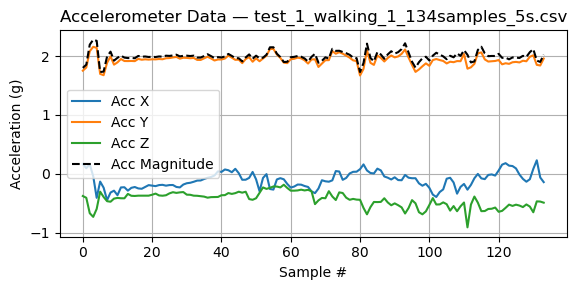

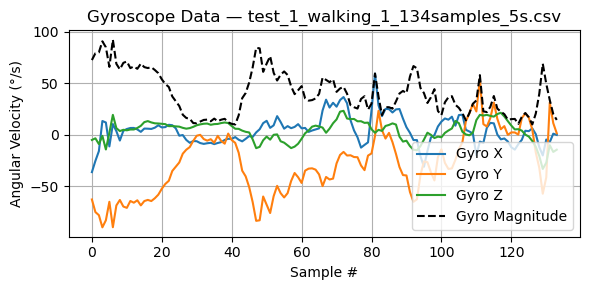

📊 Visualizing: test_1_falling_15_125samples_5s.csv


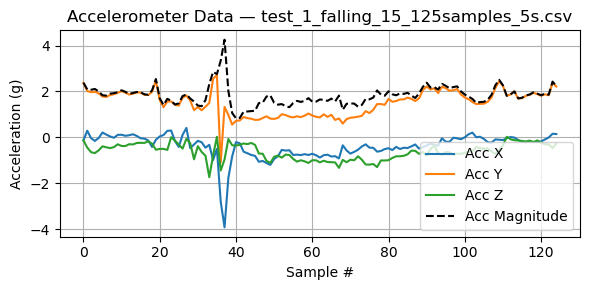

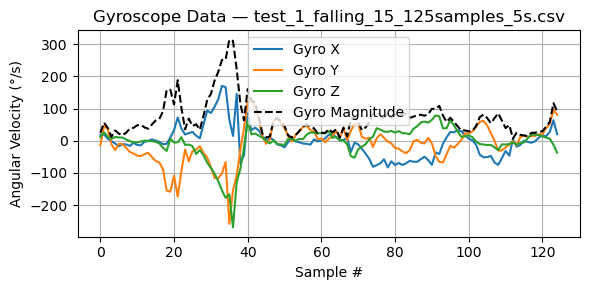

📊 Visualizing: test_1_walking_20_135samples_5s.csv


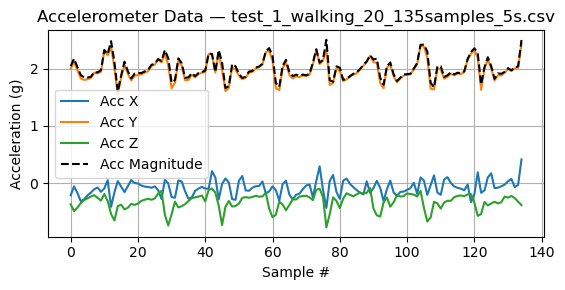

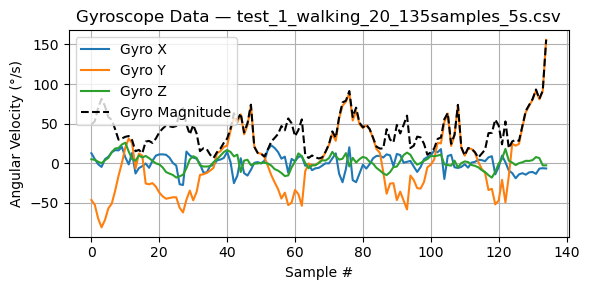

📊 Visualizing: test_1_falling_19_124samples_5s.csv


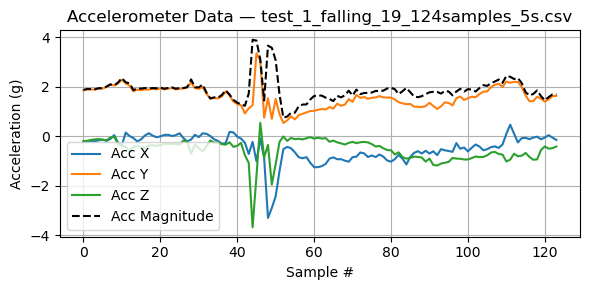

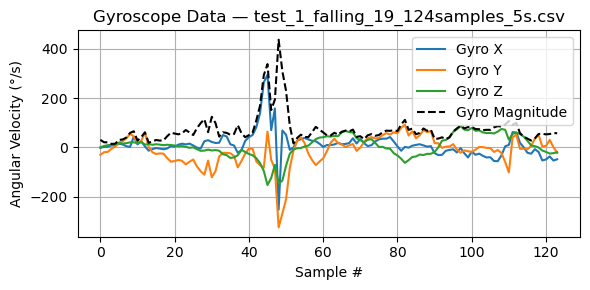

📊 Visualizing: test_1_walking_19_124samples_5s.csv


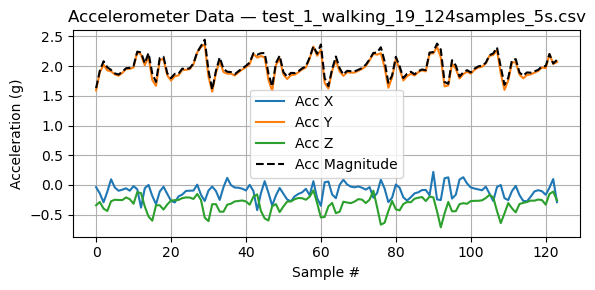

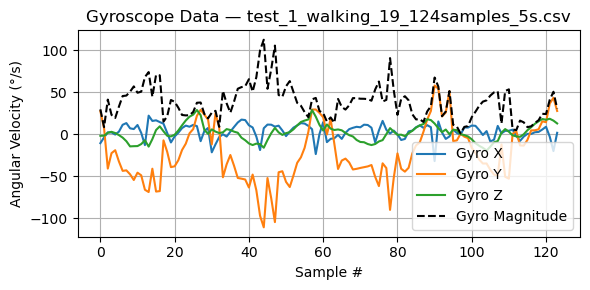

📊 Visualizing: test_1_walking_18_131samples_5s.csv


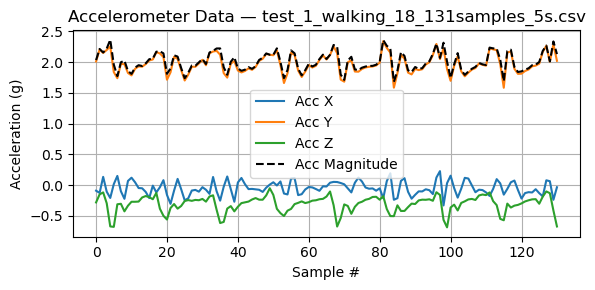

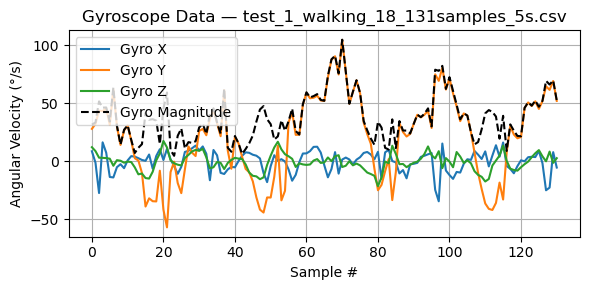

📊 Visualizing: test_1_falling_7_125samples_5s.csv


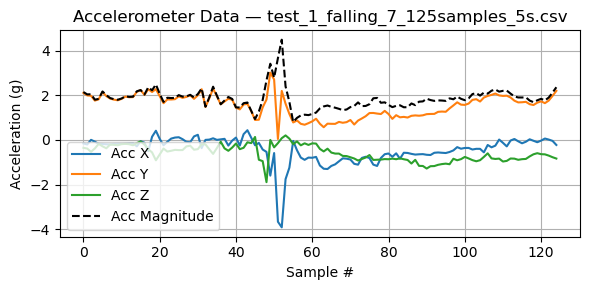

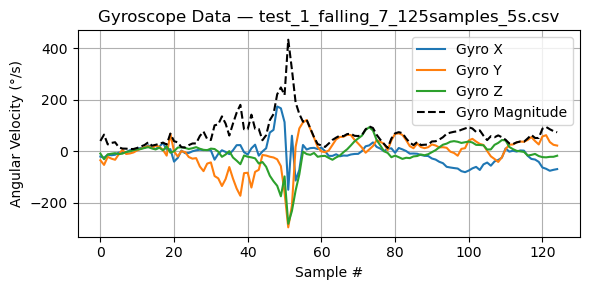

📊 Visualizing: test_1_walking_15_124samples_5s.csv


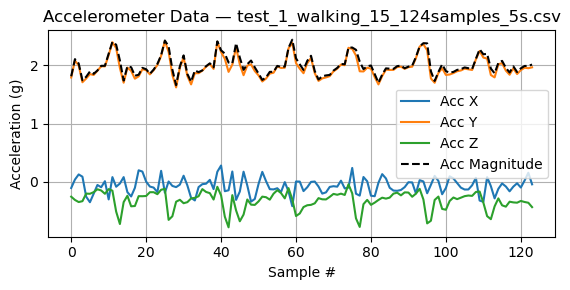

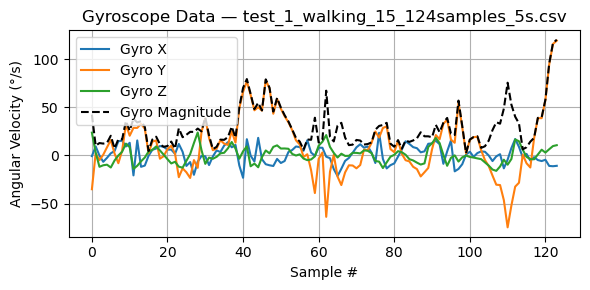

📊 Visualizing: test_1_falling_10_124samples_5s.csv


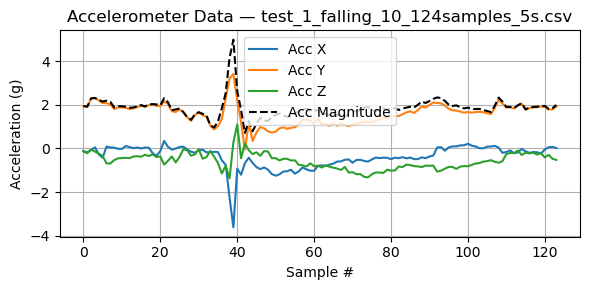

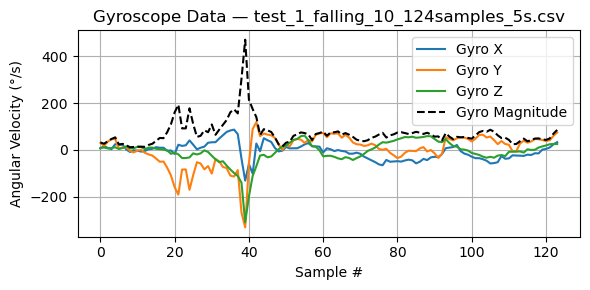

📊 Visualizing: test_1_falling_2_125samples_5s.csv


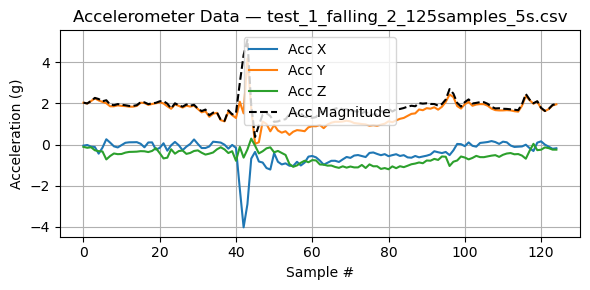

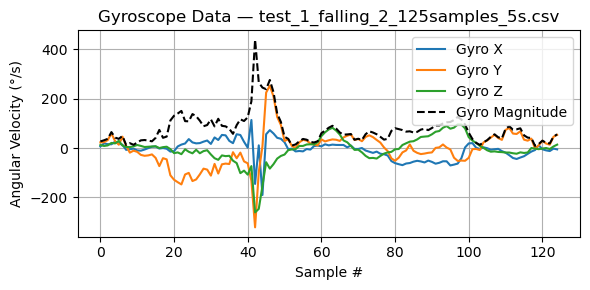

📊 Visualizing: test_1_falling_20_124samples_5s.csv


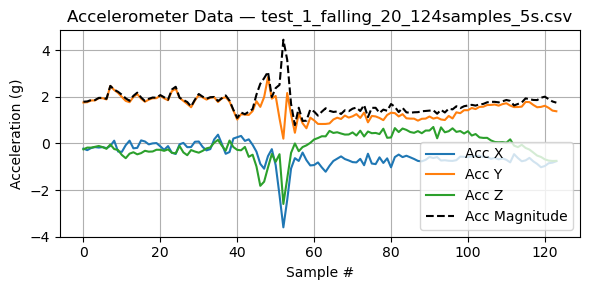

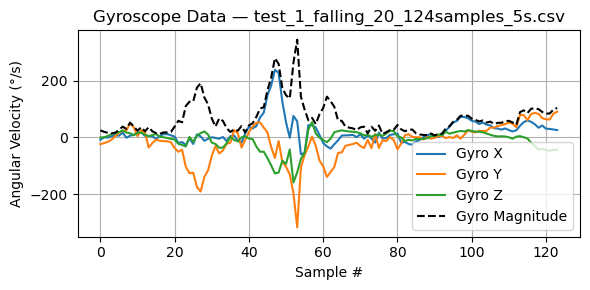

📊 Visualizing: test_1_walking_9_144samples_5s.csv


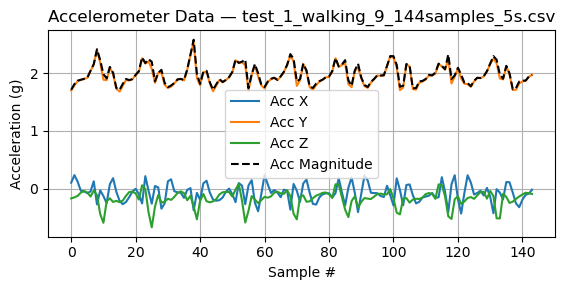

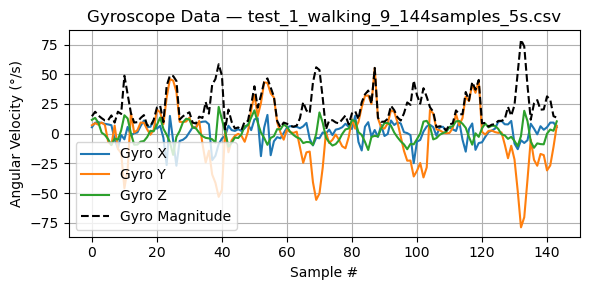

📊 Visualizing: test_1_walking_14_124samples_5s.csv


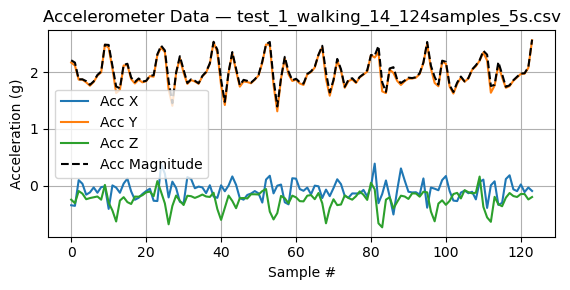

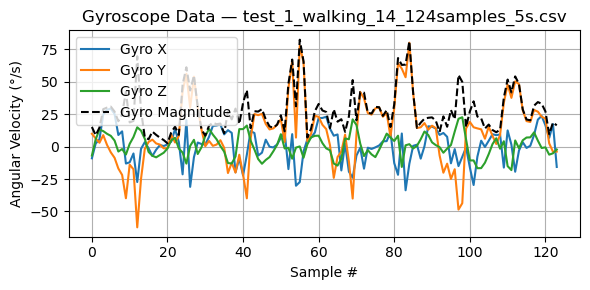

📊 Visualizing: test_1_walking_5_135samples_5s.csv


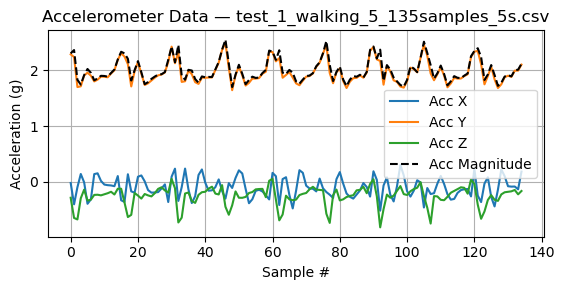

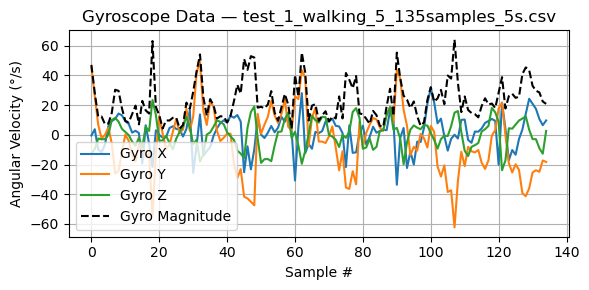

📊 Visualizing: test_1_falling_3_125samples_5s.csv


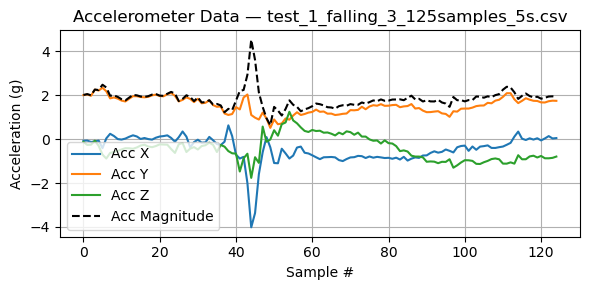

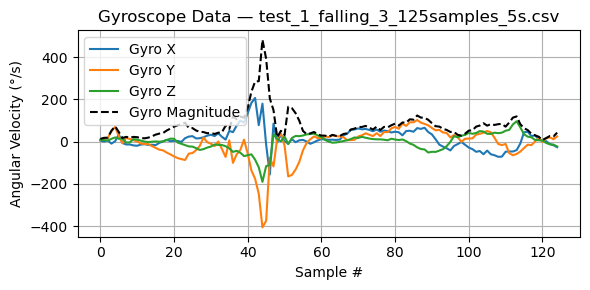

📊 Visualizing: test_1_walking_12_124samples_5s.csv


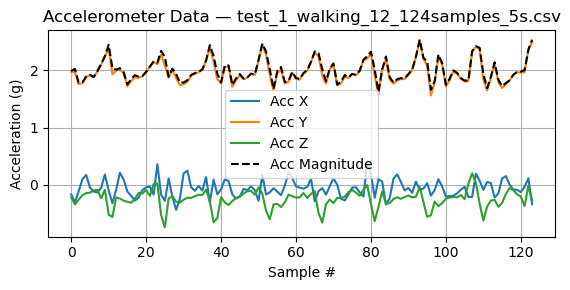

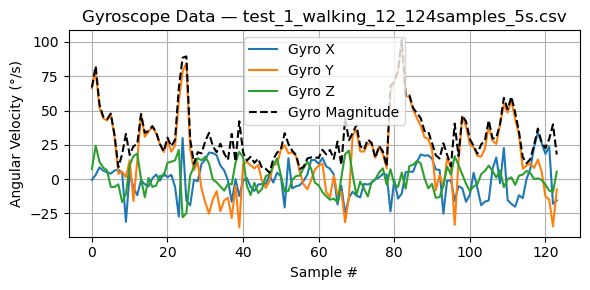

📊 Visualizing: test_1_falling_9_124samples_5s.csv


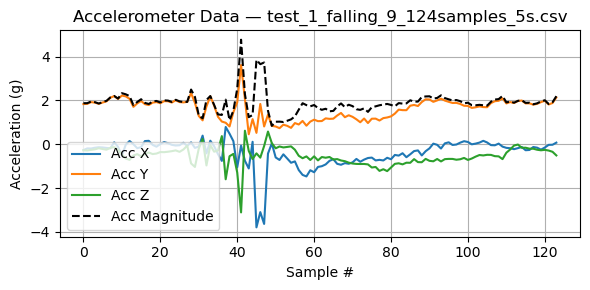

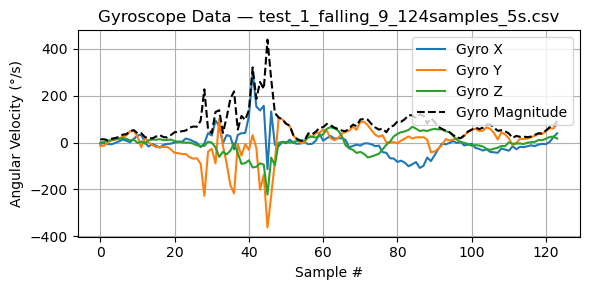

📊 Visualizing: test_1_walking_4_138samples_5s.csv


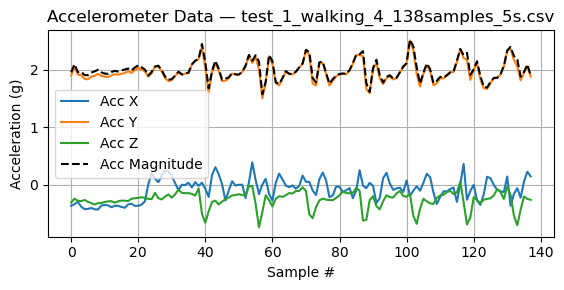

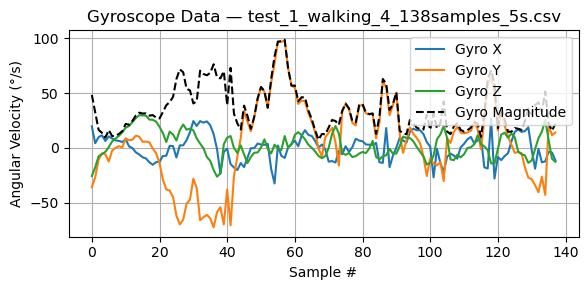

📊 Visualizing: test_1_falling_16_119samples_5s.csv


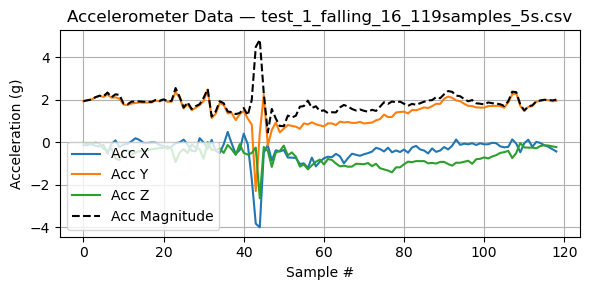

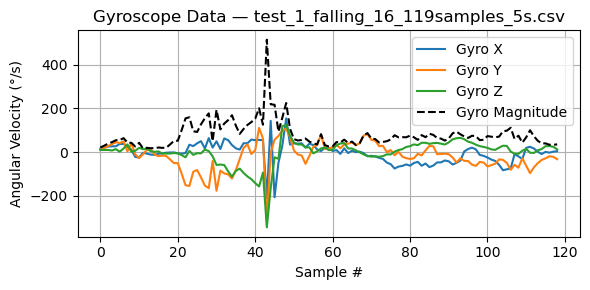

📊 Visualizing: test_1_walking_17_134samples_5s.csv


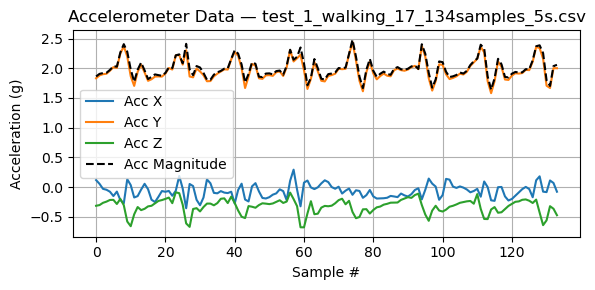

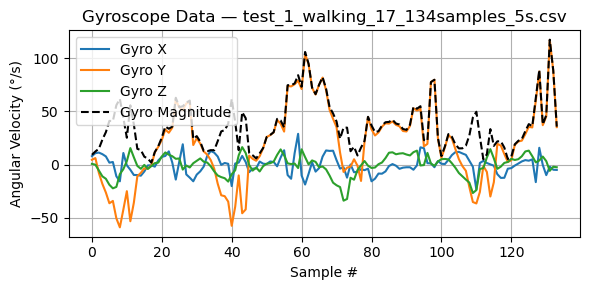

📊 Visualizing: test_1_falling_4_125samples_5s.csv


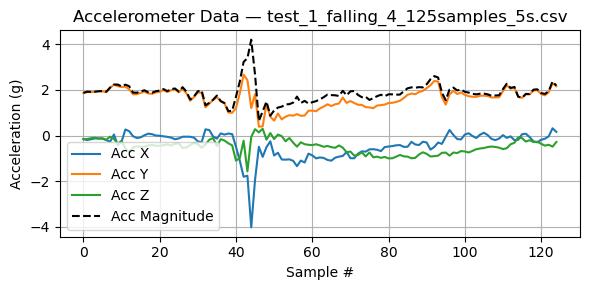

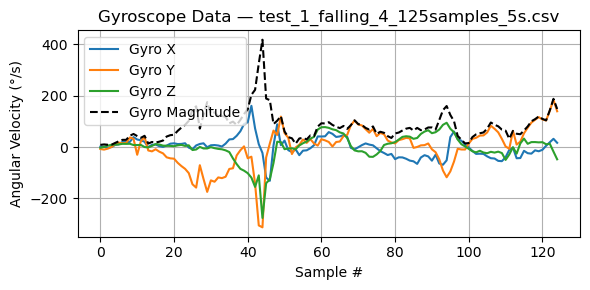

📊 Visualizing: test_1_walking_7_135samples_5s.csv


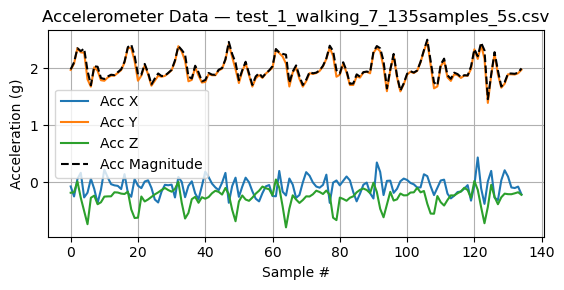

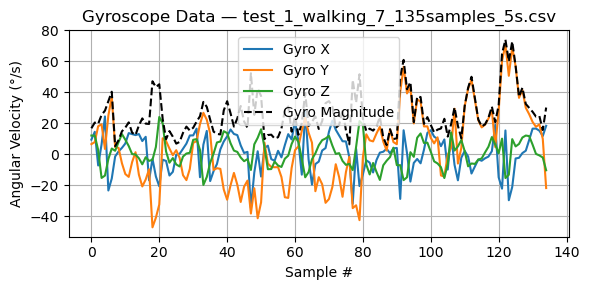

📊 Visualizing: test_1_walking_3_136samples_5s.csv


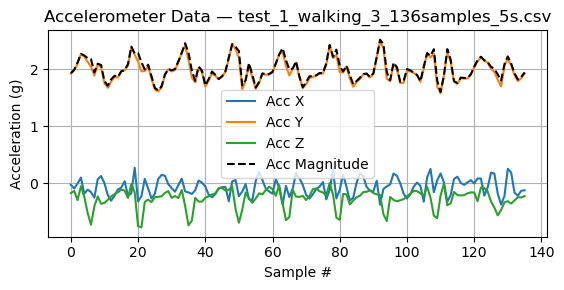

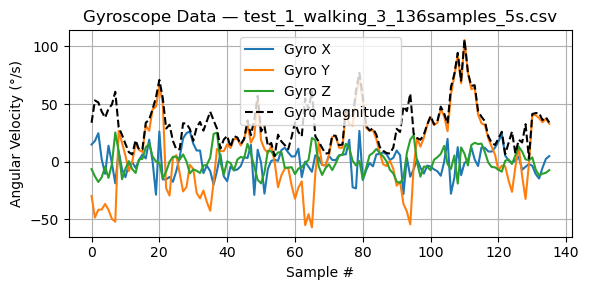

📊 Visualizing: test_1_falling_13_124samples_5s.csv


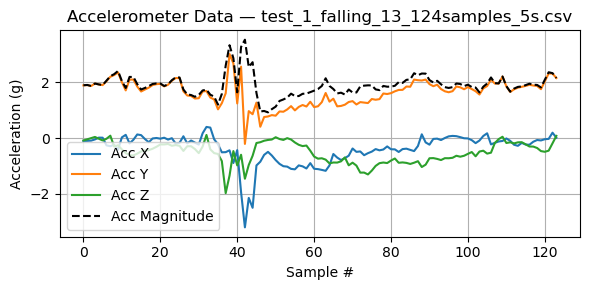

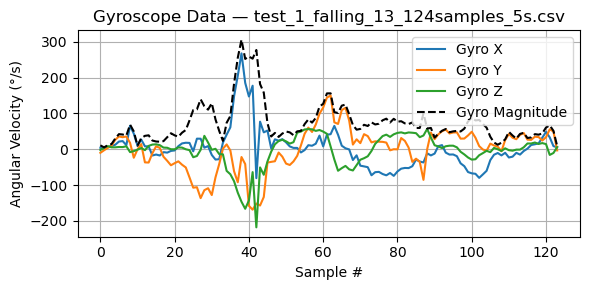


✅ Visualization complete for all CSV files.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# ─── Configuration ─────────────────────────────────────────────
FOLDER_PATH = "data/test_1_20251024"   # path to your test folder


# ─── Verify Folder ─────────────────────────────────────────────
if not os.path.exists(FOLDER_PATH):
    print(f"❌ Folder not found: {FOLDER_PATH}")
else:
    csv_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".csv")]
    if not csv_files:
        print(f"⚠️ No CSV files found in {FOLDER_PATH}")
    else:
        print(f"📁 Found {len(csv_files)} CSV files in {FOLDER_PATH}\n")

        # ─── Loop Through Each CSV File ─────────────────────────
        for csv_file in csv_files:
            file_path = os.path.join(FOLDER_PATH, csv_file)
            print(f"📊 Visualizing: {csv_file}")

            # Load CSV
            try:
                df = pd.read_csv(file_path)
            except Exception as e:
                print(f"⚠️ Could not read {csv_file}: {e}")
                continue

            required_cols = {"acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"}
            if not required_cols.issubset(df.columns):
                print(f"⚠️ Skipping {csv_file}: missing required columns.")
                continue

            # Compute magnitude for visualization
            df["acc_mag"] = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
            df["gyro_mag"] = np.sqrt(df["gyro_x"]**2 + df["gyro_y"]**2 + df["gyro_z"]**2)

            time_axis = np.arange(len(df))

            # ─── Accelerometer Plot ─────────────────────────────
            plt.figure(figsize=(6, 3))
            plt.plot(time_axis, df["acc_x"], label="Acc X")
            plt.plot(time_axis, df["acc_y"], label="Acc Y")
            plt.plot(time_axis, df["acc_z"], label="Acc Z")
            plt.plot(time_axis, df["acc_mag"], label="Acc Magnitude", color="black", linestyle="--", linewidth=1.5)
            plt.title(f"Accelerometer Data — {csv_file}")
            plt.xlabel("Sample #")
            plt.ylabel("Acceleration (g)")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            # ─── Gyroscope Plot ─────────────────────────────
            plt.figure(figsize=(6, 3))
            plt.plot(time_axis, df["gyro_x"], label="Gyro X")
            plt.plot(time_axis, df["gyro_y"], label="Gyro Y")
            plt.plot(time_axis, df["gyro_z"], label="Gyro Z")
            plt.plot(time_axis, df["gyro_mag"], label="Gyro Magnitude", color="black", linestyle="--", linewidth=1.5)
            plt.title(f"Gyroscope Data — {csv_file}")
            plt.xlabel("Sample #")
            plt.ylabel("Angular Velocity (°/s)")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        print("\n✅ Visualization complete for all CSV files.")


📁 Found 40 CSV files in data/test_1_20251024

📊 Overall Sampling Interval Statistics (ms)
min_ms    : 34.917
max_ms    : 1148.019
mean_ms   : 39.303
median_ms : 36.995
mode_ms   : 36.986


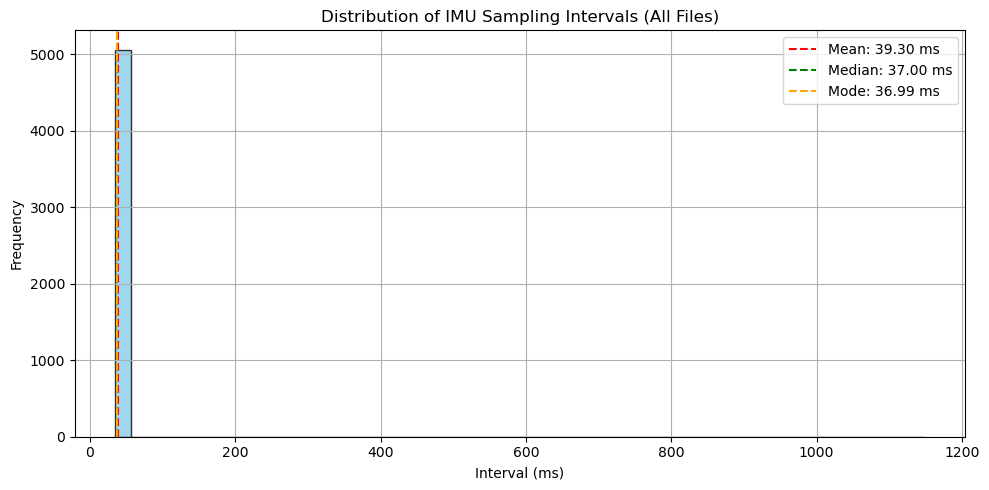


📁 Per-File Sampling Interval Summary (ms):
                               file  min_ms   max_ms   mean_ms  median_ms  mode_ms  samples
 test_1_walking_2_134samples_5s.csv  35.887   37.910 36.968902    36.9750   36.954      133
 test_1_walking_8_128samples_5s.csv  35.885   38.394 36.564669    36.7940   37.044      127
test_1_walking_13_125samples_5s.csv  35.828   51.927 40.031419    37.0470   36.982      124
 test_1_falling_1_124samples_5s.csv  35.961   51.179 39.996528    37.0420   36.830      123
 test_1_falling_5_124samples_5s.csv  36.455   51.354 39.964992    37.1040   37.104      123
test_1_walking_16_135samples_5s.csv  35.826   38.740 36.759873    36.9275   36.984      134
test_1_falling_17_125samples_5s.csv  36.205   51.236 39.923129    37.0820   36.930      124
 test_1_falling_8_122samples_5s.csv  35.951   51.816 39.989388    37.0360   36.975      121
test_1_falling_12_125samples_5s.csv  36.000   51.835 40.009613    37.0490   37.003      124
 test_1_falling_6_124samples_5s.csv 

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import mode, StatisticsError

# ─── Configuration ─────────────────────────────────────────────
FOLDER_PATH = "data/test_1_20251024"  # folder with IMU CSV files
SHOW_PER_FILE = True                  # show per-file stats (set False to only show overall)

# ─── Verify Folder ─────────────────────────────────────────────
if not os.path.exists(FOLDER_PATH):
    print(f"❌ Folder not found: {FOLDER_PATH}")
else:
    csv_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".csv")]
    if not csv_files:
        print(f"⚠️ No CSV files found in {FOLDER_PATH}")
    else:
        print(f"📁 Found {len(csv_files)} CSV files in {FOLDER_PATH}\n")

        all_intervals = []
        summary_rows = []

        # ─── Process Each CSV File ─────────────────────────────
        for csv_file in csv_files:
            path = os.path.join(FOLDER_PATH, csv_file)
            try:
                df = pd.read_csv(path)
            except Exception as e:
                print(f"⚠️ Could not read {csv_file}: {e}")
                continue

            if "t" not in df.columns:
                print(f"⚠️ Skipping {csv_file}: missing 't' timestamp column")
                continue

            # Calculate intervals
            df["dt"] = df["t"].diff()
            df = df.dropna()
            # Handle micros() rollover if needed
            df.loc[df["dt"] < 0, "dt"] += 2**32
            df["dt_sec"] = df["dt"] / 1_000_000.0  # convert µs to s

            intervals = df["dt_sec"].values
            all_intervals.extend(intervals)

            try:
                mode_val = mode(np.round(intervals, 6))
            except StatisticsError:
                mode_val = np.nan

            row = {
                "file": csv_file,
                "min_ms": np.min(intervals) * 1000,
                "max_ms": np.max(intervals) * 1000,
                "mean_ms": np.mean(intervals) * 1000,
                "median_ms": np.median(intervals) * 1000,
                "mode_ms": mode_val * 1000 if not np.isnan(mode_val) else np.nan,
                "samples": len(intervals),
            }
            summary_rows.append(row)

        # ─── Combine All ───────────────────────────────────────
        if not all_intervals:
            print("⚠️ No interval data found.")
        else:
            all_intervals = np.array(all_intervals)
            overall = {
                "min_ms": np.min(all_intervals) * 1000,
                "max_ms": np.max(all_intervals) * 1000,
                "mean_ms": np.mean(all_intervals) * 1000,
                "median_ms": np.median(all_intervals) * 1000,
            }
            try:
                overall["mode_ms"] = mode(np.round(all_intervals, 6)) * 1000
            except StatisticsError:
                overall["mode_ms"] = np.nan

            print("📊 Overall Sampling Interval Statistics (ms)")
            for k, v in overall.items():
                print(f"{k:10s}: {v:.3f}")

            # ─── Distribution Plot ─────────────────────────────
            plt.figure(figsize=(10, 5))
            plt.hist(all_intervals * 1000, bins=50, color="skyblue", edgecolor="k", alpha=0.8)
            plt.axvline(overall["mean_ms"], color="red", linestyle="--", label=f"Mean: {overall['mean_ms']:.2f} ms")
            plt.axvline(overall["median_ms"], color="green", linestyle="--", label=f"Median: {overall['median_ms']:.2f} ms")
            plt.axvline(overall["mode_ms"], color="orange", linestyle="--", label=f"Mode: {overall['mode_ms']:.2f} ms")
            plt.title("Distribution of IMU Sampling Intervals (All Files)")
            plt.xlabel("Interval (ms)")
            plt.ylabel("Frequency")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            # ─── Per-File Summary Table ────────────────────────
            if SHOW_PER_FILE:
                print("\n📁 Per-File Sampling Interval Summary (ms):")
                summary_df = pd.DataFrame(summary_rows)
                print(summary_df.to_string(index=False))
